![alt text](header.png)

### MLP-based model training 

#### Libraries

In [1]:
import os
import numpy as np
from numpy import array
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd

## Tensorflow + Keras libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD, Adam
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.sparsity.keras import prune, pruning_callbacks, pruning_schedule
from tensorflow_model_optimization.sparsity.keras import strip_pruning

## Quantization
from qkeras import *

## Datasets
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import fashion_mnist


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

2026-04-20 15:32:49.020042: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 15:32:49.071413: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-20 15:32:49.281573: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-20 15:32:49.282585: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-20 15:32:50.115192: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

#### Enable GPU 

In [2]:
# GPU
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'

import tensorflow as tf
print("GPUs: ", len(tf.config.experimental.list_physical_devices('GPU')))

import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

    except RuntimeError as e:
        print(e)

GPUs:  0


#### Load dataset

In [3]:
# Fashion MNIST
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train_norm, x_test_norm = x_train / 255.0, x_test / 255.0          


4422102/4422102 [==============================] - 0s 0us/step


#### Fashion MNIST: classes

| Label | Class |  
|-----------|-----------|
|0  | T-shirt/top	   |
|1	|Trouser    |
|2	|Pullover|
|3	|Dress|
|4	|Coat|
|5	|Sandal|
|6	|Shirt|
|7	|Sneaker|
|8	|Bag	|
|9	|Ankle boot|

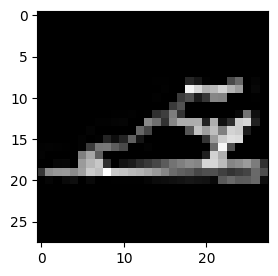

In [4]:
# Image index

N = 300

plt.figure(figsize=(3,3))
plt.imshow(x_train[N], cmap='gray')

In [5]:
# Labels
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

### Model definition



In [6]:
# MLP architecture

w = 28
h = 28
n_classes = 10

model= Sequential([

    Flatten(input_shape=(w, h)),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')

])


2026-04-20 15:32:55.616623: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x5efbac8d0350 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-04-20 15:32:55.616653: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): Host, Default Version


### Build model

In [7]:
lr = 0.001
# op = Adam(lr)
op = SGD(lr)

model.compile(loss='sparse_categorical_crossentropy', optimizer=op, metrics=['accuracy'])

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 256)               200960    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                16448     
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 10)                330       
                                                                 
Total params: 219,818
Trainable params: 219,818
Non-trai

### Model training

In [9]:
history = model.fit(x_train_norm, y_train, epochs= 32, batch_size = 50, validation_split=0.2)

Epoch 1/32
960/960 [==============================] - 2s 2ms/step - loss: 2.0421 - accuracy: 0.2627 - val_loss: 1.6855 - val_accuracy: 0.3981
Epoch 2/32
960/960 [==============================] - 1s 1ms/step - loss: 1.4582 - accuracy: 0.5294 - val_loss: 1.1545 - val_accuracy: 0.6550
Epoch 3/32
960/960 [==============================] - 1s 1ms/step - loss: 1.0988 - accuracy: 0.6425 - val_loss: 0.9208 - val_accuracy: 0.7012
Epoch 4/32
960/960 [==============================] - 1s 1ms/step - loss: 0.9270 - accuracy: 0.6823 - val_loss: 0.8062 - val_accuracy: 0.7247
Epoch 5/32
960/960 [==============================] - 1s 1ms/step - loss: 0.8369 - accuracy: 0.7109 - val_loss: 0.7374 - val_accuracy: 0.7512
Epoch 6/32
960/960 [==============================] - 1s 1ms/step - loss: 0.7798 - accuracy: 0.7326 - val_loss: 0.6906 - val_accuracy: 0.7690
Epoch 7/32
960/960 [==============================] - 1s 1ms/step - loss: 0.7293 - accuracy: 0.7504 - val_loss: 0.6564 - val_accuracy: 0.7801
Epoch 

In [10]:
# Model evaluation
test_loss, test_acc = model.evaluate(x_test_norm, y_test)
print(f"\nTest accuracy: {test_acc:.4f}")

313/313 [==============================] - 0s 641us/step - loss: 0.4685 - accuracy: 0.8357

Test accuracy: 0.8357


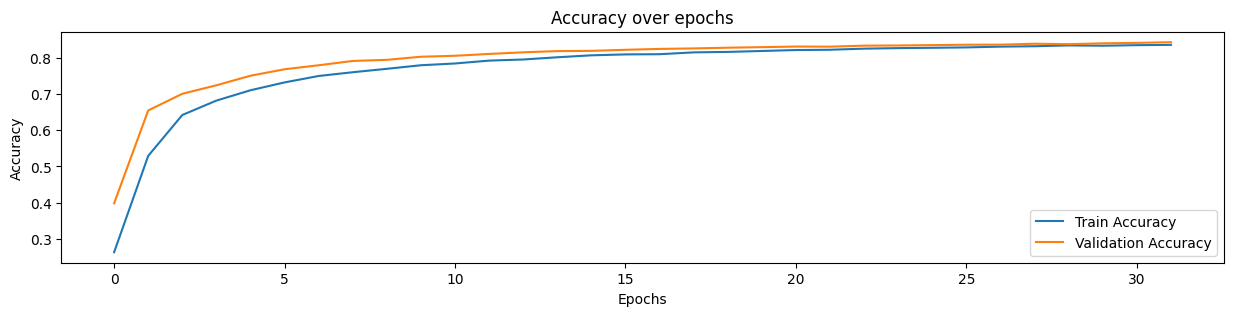

In [11]:
# Plot accuracy over epochs
plt.figure(figsize=(15,3))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over epochs')
plt.show()

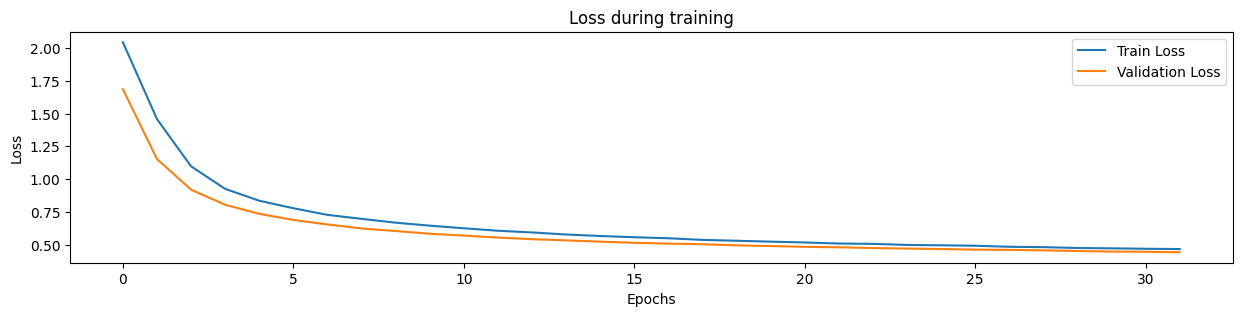

In [12]:
# Plot accuracy over loss
plt.figure(figsize=(15,3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.legend()
plt.show()

### Inference test

1/1 [==============================] - 0s 60ms/step
Predicted Class: 0 | True label: 0


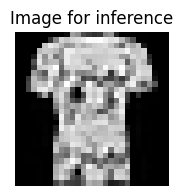

In [13]:
index = 400

plt.figure(figsize=(2,2))
plt.imshow(x_test[index], cmap='gray')
plt.axis("off")
plt.title("Image for inference")

x_in = x_test_norm[index].reshape(1, 28,28)

y_pred = model.predict(x_in)
pred_class = np.argmax(y_pred, axis=1)[0]

print(f"Predicted Class: {pred_class} | True label: {y_test[index]}")


### Confusion Matrix

313/313 [==============================] - 0s 563us/step


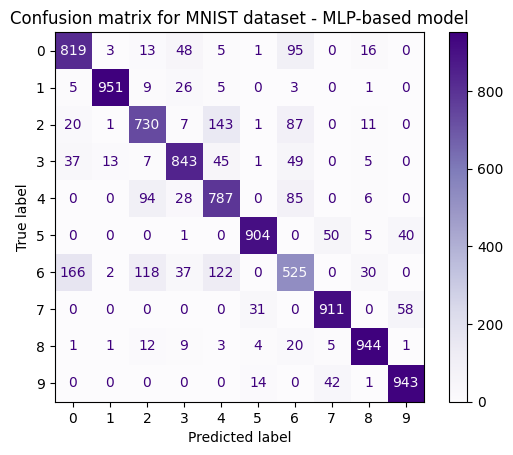

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, roc_auc_score


y_pred_probs = model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Purples')
plt.title('Confusion matrix for MNIST dataset - MLP-based model')
plt.show()

In [15]:
model.save("fashionMNIST.h5")